# Unsupervised Pet Breed Discovery — VGG16 Pipeline

This notebook follows the same experimental structure as the ResNet-18 / ViT pipeline,
using VGG16 as the feature extractor instead.

**Datasets:**
- Imagewoof (10 dog breeds, ImageNet source)
- Oxford Dogs (25 dog breeds, Flickr source — independent of ImageNet)
- Oxford Cats (12 cat breeds, Flickr source — independent of ImageNet)

**Experiments:**
- Experiment 1: SAM background removal (Baseline vs Black bg vs White bg)
- Experiment 2: Controlled lighting robustness
- Experiment 3: VGG16 vs ResNet-18 vs ViT-B/16 vs ViT-L/16 comparison

**Runtime:** A100 GPU recommended (Runtime > Change runtime type > A100)

---

## Cell 1 — Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
SAVE_DIR = '/content/drive/MyDrive/vgg16_breed_pipeline/'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'Save directory ready: {SAVE_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Save directory ready: /content/drive/MyDrive/vgg16_breed_pipeline/


## Cell 2 — Install SAM

In [ ]:
!pip install segment-anything -q
!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

import os
print(f'SAM installed: OK')
print(f'Checkpoint exists: {os.path.exists("sam_vit_b_01ec64.pth")}')
print(f'Checkpoint size: {os.path.getsize("sam_vit_b_01ec64.pth") / 1e6:.0f} MB')

SAM installed: OK
Checkpoint exists: True
Checkpoint size: 375 MB


## Cell 3 — Imports and Device Setup

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, random_split, ConcatDataset, Subset

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    confusion_matrix
)
from sklearn.manifold import TSNE
from tqdm import tqdm
from collections import defaultdict
import pandas as pd
import time
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch version : {torch.__version__}')
print(f'Device          : {device}')
if torch.cuda.is_available():
    print(f'GPU             : {torch.cuda.get_device_name(0)}')

PyTorch version : 2.10.0+cu128
Device          : cuda
GPU             : Tesla T4


## Cell 4 — Download and Load Imagewoof

Imagewoof contains 10 dog breeds sourced from ImageNet.
VGG16 was pretrained on ImageNet so it has seen these breed categories.

In [ ]:
# Download Imagewoof
!wget -q https://s3.amazonaws.com/fast-ai-imageclas/imagewoof2-160.tgz
!tar -xzf imagewoof2-160.tgz

# VGG16 expects 224x224 input, same as ResNet
# Note: VGG16 uses the same ImageNet normalization as ResNet
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

BREED_NAMES = {
    'n02086240': 'Shih-Tzu',
    'n02087394': 'Rhodesian Ridgeback',
    'n02088364': 'Beagle',
    'n02089973': 'English Foxhound',
    'n02093754': 'Australian Terrier',
    'n02096294': 'Border Terrier',
    'n02099601': 'Golden Retriever',
    'n02105641': 'Old English Sheepdog',
    'n02111889': 'Samoyed',
    'n02115641': 'Shiba Inu'
}

full_dataset = torchvision.datasets.ImageFolder(
    root='./imagewoof2-160/train',
    transform=transform
)
readable_names = [BREED_NAMES.get(c, c) for c in full_dataset.classes]

print(f'Total images : {len(full_dataset)}')
print(f'Breeds       : {len(full_dataset.classes)}')
for i, name in enumerate(readable_names):
    count = sum(1 for _, label in full_dataset if label == i)
    print(f'  {i:2d}. {name:<25} {count} images')

Total images : 9025
Breeds       : 10
   0. Shih-Tzu                  941 images
   1. Rhodesian Ridgeback       942 images
   2. Beagle                    932 images
   3. English Foxhound          580 images
   4. Australian Terrier        949 images
   5. Border Terrier            943 images
   6. Golden Retriever          949 images
   7. Old English Sheepdog      928 images
   8. Samoyed                   921 images
   9. Shiba Inu                 940 images


## Cell 5 — Split Imagewoof Dataset

In [ ]:
train_size = int(0.8 * len(full_dataset))
val_size   = int(0.1 * len(full_dataset))
test_size  = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print(f'Training   : {len(train_dataset)}')
print(f'Validation : {len(val_dataset)}')
print(f'Test       : {len(test_dataset)}')

Training   : 7220
Validation : 902
Test       : 903


## Cell 6 — Load VGG16 Feature Extractor

VGG16 architecture overview:
- 13 convolutional layers in 5 blocks
- 3 fully connected layers
- We remove the final classification layer and keep up to the second FC layer
- Output: 4096-dimensional feature vector (vs ResNet-18's 512)

Key difference from ResNet-18:
- VGG16 produces 4096 features vs ResNet-18's 512
- VGG16 has no residual connections
- VGG16 is ~8x slower for feature extraction
- VGG16 uses more memory (~528MB vs ~45MB for ResNet-18)

In [ ]:
print('Loading VGG16...')
vgg16 = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

# VGG16 structure:
# vgg16.features     -> convolutional layers
# vgg16.avgpool      -> adaptive average pooling
# vgg16.classifier   -> [FC(25088->4096), ReLU, Dropout,
#                         FC(4096->4096), ReLU, Dropout,
#                         FC(4096->1000)]  <- remove this last layer
#
# We extract features AFTER the second FC layer (4096 dimensions)
# This is equivalent to what ResNet-18 does with its avgpool output

class VGG16FeatureExtractor(torch.nn.Module):
    def __init__(self, vgg_model):
        super().__init__()
        self.features  = vgg_model.features
        self.avgpool   = vgg_model.avgpool
        # Keep first 6 layers of classifier (up to second ReLU, before final FC)
        self.classifier = torch.nn.Sequential(*list(vgg_model.classifier.children())[:-1])

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

vgg16_extractor = VGG16FeatureExtractor(vgg16)
vgg16_extractor.eval()
vgg16_extractor = vgg16_extractor.to(device)

# Verify output shape
dummy = torch.randn(1, 3, 224, 224).to(device)
with torch.no_grad():
    out = vgg16_extractor(dummy)
print(f'VGG16 feature extractor ready')
print(f'Output shape : {out.shape}  (expected [1, 4096])')
print(f'Parameters   : {sum(p.numel() for p in vgg16_extractor.parameters()):,}')
print()
print('Architecture note:')
print('  ResNet-18 output : 512 dimensions')
print('  VGG16 output     : 4096 dimensions (8x more features)')

Loading VGG16...
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:06<00:00, 81.0MB/s]


VGG16 feature extractor ready
Output shape : torch.Size([1, 4096])  (expected [1, 4096])
Parameters   : 134,260,544

Architecture note:
  ResNet-18 output : 512 dimensions
  VGG16 output     : 4096 dimensions (8x more features)


## Cell 7 — Load SAM

In [ ]:
from segment_anything import sam_model_registry, SamPredictor

sam = sam_model_registry['vit_b'](checkpoint='sam_vit_b_01ec64.pth')
sam = sam.to(device)
predictor = SamPredictor(sam)

print(f'SAM ViT-B loaded on {device}')

SAM ViT-B loaded on cuda


## Cell 8 — Helper Functions

These functions are reused across all experiments and datasets.

In [ ]:
# ---- Normalize ----
def normalize(train_feat, val_feat):
    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(train_feat)
    val_scaled   = scaler.transform(val_feat)
    return train_scaled, val_scaled, scaler


# ---- K-Means Clustering ----
def run_kmeans(train_features, val_features, train_labels, val_labels,
               pipeline_name, n_breeds=10):
    print(f'\n{"="*55}')
    print(f'Pipeline: {pipeline_name}')
    print(f'{"="*55}')

    k_range    = [5, 8, 10, 12, 15, 20]
    sil_scores = []

    print('Testing K values:')
    for k in k_range:
        km  = KMeans(n_clusters=k, random_state=42, n_init=10)
        cls = km.fit_predict(train_features)
        sil = silhouette_score(train_features, cls)
        sil_scores.append(sil)
        print(f'  K={k:2d}  Silhouette={sil:.4f}')

    best_k   = k_range[np.argmax(sil_scores)]
    best_sil = max(sil_scores)
    print(f'\nBest K: {best_k}  (Silhouette: {best_sil:.4f})')

    final_km       = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    train_clusters = final_km.fit_predict(train_features)
    val_clusters   = final_km.predict(val_features)

    if best_k != n_breeds:
        km_true       = KMeans(n_clusters=n_breeds, random_state=42, n_init=10)
        clusters_true = km_true.fit_predict(train_features)
        sil_true      = silhouette_score(train_features, clusters_true)
        print(f'K={n_breeds} (true breed count)  Silhouette={sil_true:.4f}')

    val_sil = silhouette_score(val_features, val_clusters)
    ari     = adjusted_rand_score(val_labels, val_clusters)
    nmi     = normalized_mutual_info_score(val_labels, val_clusters)

    print(f'\nValidation metrics:')
    print(f'  Silhouette : {val_sil:.4f}')
    print(f'  ARI        : {ari:.4f}')
    print(f'  NMI        : {nmi:.4f}')

    return {
        'name'          : pipeline_name,
        'best_k'        : best_k,
        'train_clusters': train_clusters,
        'val_clusters'  : val_clusters,
        'final_km'      : final_km,
        'silhouette'    : val_sil,
        'ari'           : ari,
        'nmi'           : nmi,
    }


# ---- Purity Analysis ----
def purity_analysis(train_clusters, train_labels, readable_names,
                    pipeline_name, n_clusters):
    print(f'\n{"="*65}')
    print(f'Purity Analysis — {pipeline_name}')
    print(f'{"="*65}')
    print(f'{"Breed":<25} {"Dom. Cluster":>12} {"Correct":>8} {"Total":>7} {"Purity":>8}  Status')
    print('-'*65)

    cm = confusion_matrix(train_labels, train_clusters)
    purity_scores     = []
    dominant_clusters = []

    for breed_idx, name in enumerate(readable_names):
        row     = cm[breed_idx]
        total   = row.sum()
        dom     = row.argmax()
        correct = row[dom]
        purity  = correct / total
        purity_scores.append(purity)
        dominant_clusters.append(dom)

        if purity >= 0.80:
            status = 'Excellent'
        elif purity >= 0.65:
            status = 'Good'
        elif purity >= 0.50:
            status = 'Moderate'
        else:
            status = 'Poor'

        print(f'{name:<25} {dom:>12} {correct:>8} {total:>7} {purity:>7.1%}  {status}')

    print('-'*65)
    print(f'{"Average":<25} {"":>12} {"":>8} {"":>7} {np.mean(purity_scores):>7.1%}')

    print(f'\nCluster Sharing Check:')
    cluster_to_breeds = defaultdict(list)
    for breed_idx, cluster in enumerate(dominant_clusters):
        cluster_to_breeds[cluster].append(readable_names[breed_idx])
    found = False
    for cluster, breeds in cluster_to_breeds.items():
        if len(breeds) > 1:
            found = True
            print(f'  Cluster {cluster} shared by: {" & ".join(breeds)}')
    if not found:
        print('  Every breed has its own dominant cluster.')

    return cm


# ---- t-SNE Visualization ----
def plot_tsne(train_features_scaled, train_labels, train_clusters,
              readable_names, best_k, pipeline_name, save_path):
    print(f'Running t-SNE for {pipeline_name}...')
    tsne        = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
    features_2d = tsne.fit_transform(train_features_scaled)
    print('t-SNE complete.')

    colors  = plt.cm.tab20(np.linspace(0, 1, max(best_k, len(readable_names))))
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    for i, name in enumerate(readable_names):
        mask = train_labels == i
        axes[0].scatter(features_2d[mask, 0], features_2d[mask, 1],
                        c=[colors[i % 20]], label=name, alpha=0.6, s=12)
    axes[0].set_title('True Breed Labels', fontsize=13, fontweight='bold')
    axes[0].legend(fontsize=6, markerscale=2)
    axes[0].set_xlabel('t-SNE Dimension 1')
    axes[0].set_ylabel('t-SNE Dimension 2')

    for i in range(best_k):
        mask = train_clusters == i
        axes[1].scatter(features_2d[mask, 0], features_2d[mask, 1],
                        c=[colors[i % 20]], label=f'Cluster {i}', alpha=0.6, s=12)
    axes[1].set_title(f'K-Means Clusters (K={best_k})', fontsize=13, fontweight='bold')
    axes[1].legend(fontsize=6, markerscale=2)
    axes[1].set_xlabel('t-SNE Dimension 1')
    axes[1].set_ylabel('t-SNE Dimension 2')

    plt.suptitle(f't-SNE Visualization — {pipeline_name}', fontsize=14)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')


# ---- Confusion Matrix Heatmap ----
def plot_confusion_heatmap(cm, readable_names, n_clusters,
                           pipeline_name, save_path):
    fig, ax   = plt.subplots(figsize=(max(12, n_clusters), 8))
    cm_norm   = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    im        = ax.imshow(cm_norm, cmap='Blues', aspect='auto', vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, label='Proportion of breed in cluster')

    ax.set_xticks(range(n_clusters))
    ax.set_xticklabels([f'C{i}' for i in range(n_clusters)], rotation=45, ha='right')
    ax.set_yticks(range(len(readable_names)))
    ax.set_yticklabels(readable_names)

    for i in range(len(readable_names)):
        for j in range(n_clusters):
            count = cm[i, j]
            if count > 0:
                color = 'white' if cm_norm[i, j] > 0.5 else 'black'
                ax.text(j, i, str(count), ha='center', va='center',
                        fontsize=7, color=color)

    ax.set_xlabel('K-Means Cluster')
    ax.set_ylabel('True Breed')
    ax.set_title(f'Confusion Matrix — {pipeline_name}\n'
                 f'(color = proportion of breed in cluster)')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')


print('All helper functions defined.')

All helper functions defined.


## Cell 9 — SAM Segmentation + Feature Extraction Function

This function runs SAM once per image and extracts VGG16 features
for both black and white backgrounds in a single pass.

**VGG16 note:** VGG16 feature extraction is ~8x slower than ResNet-18
per image due to the larger network size (138M vs 11.7M parameters).
Expect longer extraction times compared to the ResNet-18 pipeline.

In [ ]:
def segment_and_extract(model, dataset, predictor, device, description='Extracting'):
    """
    Single-pass extraction for baseline, black bg, and white bg.
    SAM runs once per image using robust multi-point prompting.
    VGG16 runs once per image for baseline, then once more for
    both SAM variants in a single batched forward pass.

    Returns:
        features_baseline : (N, 4096)
        features_black    : (N, 4096)
        features_white    : (N, 4096)
        labels            : (N,)
    """
    model.eval()
    feat_baseline     = []
    feat_black        = []
    feat_white        = []
    labels_list       = []
    coverage_warnings = []

    for idx in tqdm(range(len(dataset)), desc=description):
        try:
            image, label = dataset[idx]

            # ---- Baseline: raw image ----
            with torch.no_grad():
                raw_feat = model(image.unsqueeze(0).to(device))
                raw_feat = raw_feat.view(1, -1).cpu().numpy()
            feat_baseline.append(raw_feat)

            # ---- SAM segmentation ----
            image_np   = image.permute(1, 2, 0).numpy()
            image_np   = (image_np * 0.5) + 0.5
            image_np   = np.clip(image_np, 0, 1)
            image_uint8 = (image_np * 255).astype(np.uint8)

            predictor.set_image(image_uint8)

            # Robust multi-point prompt (5 points across center region)
            h, w = image_uint8.shape[:2]
            prompt_points = np.array([
                [w // 2,       h // 2      ],
                [w // 2,       h // 3      ],
                [w // 2,       2 * h // 3  ],
                [w // 3,       h // 2      ],
                [2 * w // 3,   h // 2      ],
            ])
            prompt_labels = np.ones(len(prompt_points), dtype=int)

            masks, scores, _ = predictor.predict(
                point_coords=prompt_points,
                point_labels=prompt_labels,
                multimask_output=True
            )

            # Pick mask with coverage between 10% and 80%
            mask       = None
            best_score = -1
            for m, s in zip(masks, scores):
                coverage = m.mean()
                if 0.10 <= coverage <= 0.80 and s > best_score:
                    mask       = m
                    best_score = s
            if mask is None:
                mask = masks[np.argmax(scores)]

            # Coverage warning
            coverage = mask.mean()
            if coverage < 0.05 or coverage > 0.95:
                coverage_warnings.append((idx, coverage))

            # ---- Apply mask ----
            mask_3d   = mask[:, :, np.newaxis]
            img_black = np.where(mask_3d, image_np, 0.0)
            img_white = np.where(mask_3d, image_np, 1.0)

            img_black = (img_black - 0.5) / 0.5
            img_white = (img_white - 0.5) / 0.5

            t_black = torch.tensor(img_black, dtype=torch.float32).permute(2, 0, 1)
            t_white = torch.tensor(img_white, dtype=torch.float32).permute(2, 0, 1)

            # ---- Extract VGG16 features for both in one batch ----
            batch = torch.stack([t_black, t_white]).to(device)
            with torch.no_grad():
                feats = model(batch).view(2, -1).cpu().numpy()

            feat_black.append(feats[0:1])
            feat_white.append(feats[1:2])
            labels_list.append(label)

        except Exception as e:
            print(f'  Failed on index {idx}: {e}')
            feat_baseline.append(np.zeros((1, 4096)))
            feat_black.append(np.zeros((1, 4096)))
            feat_white.append(np.zeros((1, 4096)))
            labels_list.append(label)

    if coverage_warnings:
        print(f'\n  {len(coverage_warnings)} images with unusual mask coverage:')
        for idx, cov in coverage_warnings[:5]:
            print(f'    Image {idx}: {cov*100:.1f}%')

    return (
        np.concatenate(feat_baseline, axis=0),
        np.concatenate(feat_black,    axis=0),
        np.concatenate(feat_white,    axis=0),
        np.array(labels_list)
    )


def extract_baseline_only(model, dataset, device, description='Extracting'):
    """Extract VGG16 features without SAM. Used for lighting experiment."""
    model.eval()
    features_list = []
    labels_list   = []
    with torch.no_grad():
        for idx in tqdm(range(len(dataset)), desc=description):
            image, label = dataset[idx]
            feat = model(image.unsqueeze(0).to(device))
            feat = feat.view(1, -1).cpu().numpy()
            features_list.append(feat)
            labels_list.append(label)
    return np.concatenate(features_list), np.array(labels_list)


print('Extraction functions defined.')
print('Note: VGG16 extracts 4096-dimensional features (vs ResNet-18 512d)')

Extraction functions defined.
Note: VGG16 extracts 4096-dimensional features (vs ResNet-18 512d)


## Cell 10 — Extract Imagewoof Features (All Three Pipelines)

This runs SAM + VGG16 on the Imagewoof training and validation sets.
Expected time on A100: 15-25 minutes (VGG16 is slower than ResNet-18).
Features are saved to Drive immediately after extraction.

In [14]:
print('='*60)
print('Imagewoof Feature Extraction — VGG16')
print('='*60)
print('Expected time: 15-25 minutes on A100')
print('VGG16 produces 4096d features vs ResNet-18 512d')
print()

t0 = time.time()

iw_train_base, iw_train_black, iw_train_white, iw_train_labels = \
    segment_and_extract(vgg16_extractor, train_dataset, predictor,
                        device, 'Imagewoof Train')

iw_val_base, iw_val_black, iw_val_white, iw_val_labels = \
    segment_and_extract(vgg16_extractor, val_dataset, predictor,
                        device, 'Imagewoof Val')

extraction_time = time.time() - t0
print(f'\nExtraction time: {extraction_time/60:.1f} minutes')
print(f'Feature shapes:')
print(f'  Baseline — Train: {iw_train_base.shape}, Val: {iw_val_base.shape}')
print(f'  Black bg — Train: {iw_train_black.shape}')
print(f'  White bg — Train: {iw_train_white.shape}')

# Save immediately
np.save(SAVE_DIR + 'iw_train_base.npy',   iw_train_base)
np.save(SAVE_DIR + 'iw_train_black.npy',  iw_train_black)
np.save(SAVE_DIR + 'iw_train_white.npy',  iw_train_white)
np.save(SAVE_DIR + 'iw_val_base.npy',     iw_val_base)
np.save(SAVE_DIR + 'iw_val_black.npy',    iw_val_black)
np.save(SAVE_DIR + 'iw_val_white.npy',    iw_val_white)
np.save(SAVE_DIR + 'iw_train_labels.npy', iw_train_labels)
np.save(SAVE_DIR + 'iw_val_labels.npy',   iw_val_labels)
print('Imagewoof features saved to Drive.')

Imagewoof Feature Extraction — VGG16
Expected time: 15-25 minutes on A100
VGG16 produces 4096d features vs ResNet-18 512d



Imagewoof Val: 100%|██████████| 902/902 [08:16<00:00,  1.82it/s]



  1 images with unusual mask coverage:
    Image 228: 3.8%

Extraction time: 74.3 minutes
Feature shapes:
  Baseline — Train: (7220, 4096), Val: (902, 4096)
  Black bg — Train: (7220, 4096)
  White bg — Train: (7220, 4096)
Imagewoof features saved to Drive.


## Cell 11 — Cluster Imagewoof (Experiment 1: SAM Variants)

In [15]:
# Normalize
iw_train_base_s,  iw_val_base_s,  _ = normalize(iw_train_base,  iw_val_base)
iw_train_black_s, iw_val_black_s, _ = normalize(iw_train_black, iw_val_black)
iw_train_white_s, iw_val_white_s, _ = normalize(iw_train_white, iw_val_white)

# Cluster all three pipelines
iw_base  = run_kmeans(iw_train_base_s,  iw_val_base_s,
                      iw_train_labels, iw_val_labels,
                      'Imagewoof Baseline (VGG16)', n_breeds=10)

iw_black = run_kmeans(iw_train_black_s, iw_val_black_s,
                      iw_train_labels, iw_val_labels,
                      'Imagewoof SAM Black bg (VGG16)', n_breeds=10)

iw_white = run_kmeans(iw_train_white_s, iw_val_white_s,
                      iw_train_labels, iw_val_labels,
                      'Imagewoof SAM White bg (VGG16)', n_breeds=10)

# Summary table
print(f'\n{"="*65}')
print('Imagewoof Pipeline Comparison — VGG16')
print(f'{"="*65}')
print(f'{"Pipeline":<35} {"Best K":>6} {"ARI":>8} {"NMI":>8}')
print('-'*65)
for r in [iw_base, iw_black, iw_white]:
    print(f'{r["name"]:<35} {r["best_k"]:>6} {r["ari"]:>8.4f} {r["nmi"]:>8.4f}')
print(f'{"="*65}')
print()
print('ResNet-18 reference scores (from teammate notebook):')
print('  Baseline : ARI=0.5800  NMI=0.6897')
print('  Black bg : ARI=0.2510  NMI=0.4113')
print('  White bg : ARI=0.1434  NMI=0.2538')


Pipeline: Imagewoof Baseline (VGG16)
Testing K values:
  K= 5  Silhouette=0.0500
  K= 8  Silhouette=0.0423
  K=10  Silhouette=0.0521
  K=12  Silhouette=0.0533
  K=15  Silhouette=0.0490
  K=20  Silhouette=0.0420

Best K: 12  (Silhouette: 0.0533)
K=10 (true breed count)  Silhouette=0.0521

Validation metrics:
  Silhouette : 0.0564
  ARI        : 0.5711
  NMI        : 0.6797

Pipeline: Imagewoof SAM Black bg (VGG16)
Testing K values:
  K= 5  Silhouette=0.0196
  K= 8  Silhouette=0.0244
  K=10  Silhouette=0.0196
  K=12  Silhouette=0.0237
  K=15  Silhouette=0.0134
  K=20  Silhouette=0.0005

Best K: 8  (Silhouette: 0.0244)
K=10 (true breed count)  Silhouette=0.0196

Validation metrics:
  Silhouette : 0.0193
  ARI        : 0.1707
  NMI        : 0.3102

Pipeline: Imagewoof SAM White bg (VGG16)
Testing K values:
  K= 5  Silhouette=0.0304
  K= 8  Silhouette=0.0240
  K=10  Silhouette=0.0237
  K=12  Silhouette=0.0181
  K=15  Silhouette=0.0181
  K=20  Silhouette=0.0118

Best K: 5  (Silhouette: 0.03

## Cell 12 — Purity Analysis and Visualizations (Imagewoof)


Purity Analysis — Imagewoof Baseline VGG16
Breed                     Dom. Cluster  Correct   Total   Purity  Status
-----------------------------------------------------------------
Shih-Tzu                             0      487     743   65.5%  Good
Rhodesian Ridgeback                  3      572     760   75.3%  Good
Beagle                              10      512     760   67.4%  Good
English Foxhound                     5      248     447   55.5%  Moderate
Australian Terrier                   4      531     765   69.4%  Good
Border Terrier                       1      576     769   74.9%  Good
Golden Retriever                     7      557     748   74.5%  Good
Old English Sheepdog                 9      585     757   77.3%  Good
Samoyed                             11      528     709   74.5%  Good
Shiba Inu                            8      559     762   73.4%  Good
-----------------------------------------------------------------
Average                                        

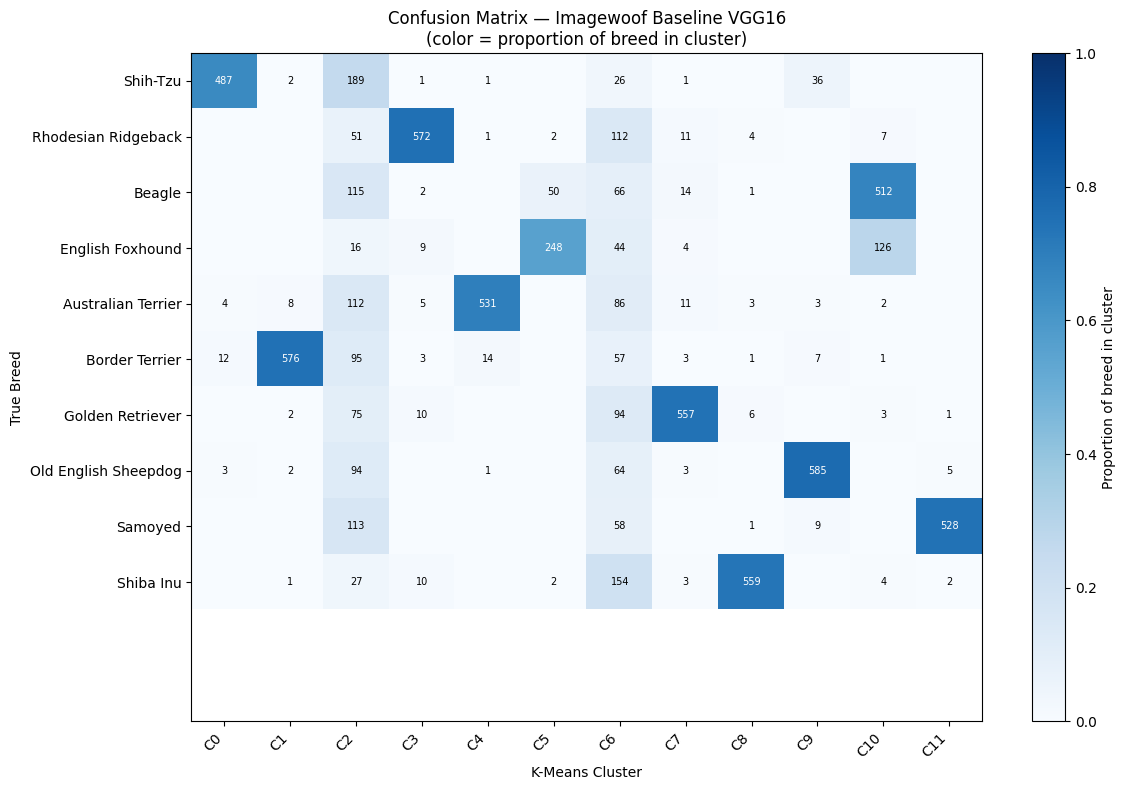

Saved: /content/drive/MyDrive/vgg16_breed_pipeline/cm_iw_baseline_vgg16.png
Running t-SNE for Imagewoof Baseline VGG16...
t-SNE complete.


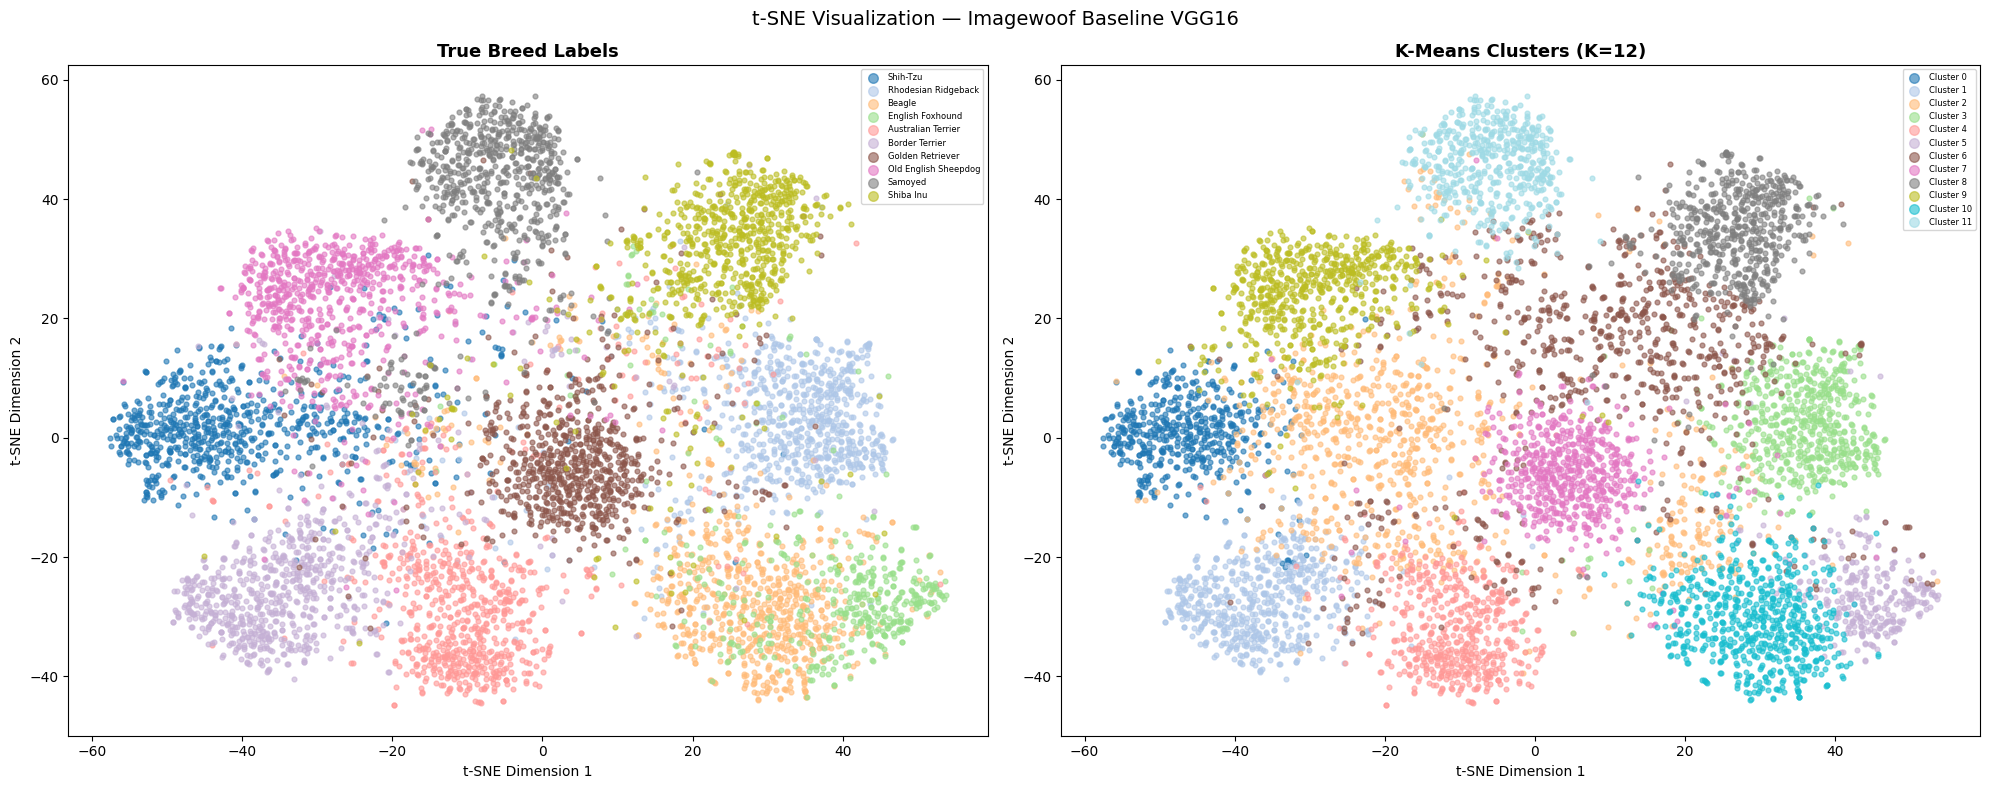

Saved: /content/drive/MyDrive/vgg16_breed_pipeline/tsne_iw_baseline_vgg16.png


In [16]:
# Purity analysis
cm_iw_base = purity_analysis(
    iw_base['train_clusters'], iw_train_labels,
    readable_names, 'Imagewoof Baseline VGG16', iw_base['best_k']
)

# Confusion matrix heatmap
plot_confusion_heatmap(
    cm_iw_base, readable_names, iw_base['best_k'],
    'Imagewoof Baseline VGG16',
    SAVE_DIR + 'cm_iw_baseline_vgg16.png'
)

# t-SNE
plot_tsne(
    iw_train_base_s, iw_train_labels, iw_base['train_clusters'],
    readable_names, iw_base['best_k'],
    'Imagewoof Baseline VGG16',
    SAVE_DIR + 'tsne_iw_baseline_vgg16.png'
)

## Cell 13 — Load Oxford Pets Dataset

In [17]:
print('Downloading Oxford Pets...')
full_pets = datasets.OxfordIIITPet(
    root='./data', split='trainval',
    target_types='category',
    transform=transform, download=True
)
test_pets = datasets.OxfordIIITPet(
    root='./data', split='test',
    target_types='category',
    transform=transform, download=True
)

CAT_CLASSES = [
    'Abyssinian', 'Bengal', 'Birman', 'Bombay', 'British Shorthair',
    'Egyptian Mau', 'Maine Coon', 'Persian', 'Ragdoll',
    'Russian Blue', 'Siamese', 'Sphynx'
]
DOG_CLASSES = [
    'American Bulldog', 'American Pit Bull Terrier', 'Basset Hound',
    'Beagle', 'Boxer', 'Chihuahua', 'English Cocker Spaniel',
    'English Setter', 'German Shorthaired', 'Great Pyrenees', 'Havanese',
    'Japanese Chin', 'Keeshond', 'Leonberger', 'Miniature Pinscher',
    'Newfoundland', 'Pomeranian', 'Pug', 'Saint Bernard', 'Samoyed',
    'Scottish Terrier', 'Shiba Inu', 'Staffordshire Bull Terrier',
    'Wheaten Terrier', 'Yorkshire Terrier'
]

class_names       = full_pets.classes
cat_label_indices = [i for i, c in enumerate(class_names) if c in CAT_CLASSES]
dog_label_indices = [i for i, c in enumerate(class_names) if c in DOG_CLASSES]

all_pets   = ConcatDataset([full_pets, test_pets])
all_labels = np.array(
    [full_pets[i][1] for i in range(len(full_pets))] +
    [test_pets[i][1]  for i in range(len(test_pets))]
)

cat_indices = np.where(np.isin(all_labels, cat_label_indices))[0]
dog_indices = np.where(np.isin(all_labels, dog_label_indices))[0]

cat_label_map = {orig: new for new, orig in enumerate(sorted(cat_label_indices))}
dog_label_map = {orig: new for new, orig in enumerate(sorted(dog_label_indices))}
cat_readable  = [class_names[i] for i in sorted(cat_label_indices)]
dog_readable  = [class_names[i] for i in sorted(dog_label_indices)]

print(f'Cat classes : {len(cat_label_indices)}')
print(f'Dog classes : {len(dog_label_indices)}')
print(f'Cat images  : {len(cat_indices)}')
print(f'Dog images  : {len(dog_indices)}')


def split_species_dataset(all_dataset, species_indices, label_map, seed=42):
    subset     = Subset(all_dataset, species_indices)
    n          = len(subset)
    train_size = int(0.8 * n)
    val_size   = int(0.1 * n)
    test_size  = n - train_size - val_size
    return torch.utils.data.random_split(
        subset, [train_size, val_size, test_size],
        generator=torch.Generator().manual_seed(seed)
    )


def get_remapped_labels(dataset, label_map):
    return np.array([label_map[dataset[i][1]] for i in range(len(dataset))])


dog_train, dog_val, dog_test = split_species_dataset(all_pets, dog_indices, dog_label_map)
cat_train, cat_val, cat_test = split_species_dataset(all_pets, cat_indices, cat_label_map)

dog_train_labels = get_remapped_labels(dog_train, dog_label_map)
dog_val_labels   = get_remapped_labels(dog_val,   dog_label_map)
cat_train_labels = get_remapped_labels(cat_train, cat_label_map)
cat_val_labels   = get_remapped_labels(cat_val,   cat_label_map)

print(f'\nDog train: {len(dog_train)}, val: {len(dog_val)}')
print(f'Cat train: {len(cat_train)}, val: {len(cat_val)}')

100%|██████████| 792M/792M [00:28<00:00, 27.5MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 13.2MB/s]


Cat classes : 12
Dog classes : 25
Cat images  : 2371
Dog images  : 4978

Dog train: 3982, val: 497
Cat train: 1896, val: 237


## Cell 14 — Extract Oxford Pets Features (Experiment 1)

In [18]:
print('='*60)
print('Oxford Dogs — Feature Extraction (VGG16)')
print('='*60)

dog_train_base, dog_train_black, dog_train_white, _ = \
    segment_and_extract(vgg16_extractor, dog_train, predictor, device, 'Dog Train')
dog_val_base, dog_val_black, dog_val_white, _ = \
    segment_and_extract(vgg16_extractor, dog_val, predictor, device, 'Dog Val')

np.save(SAVE_DIR + 'oxford_dog_train_base.npy',  dog_train_base)
np.save(SAVE_DIR + 'oxford_dog_train_black.npy', dog_train_black)
np.save(SAVE_DIR + 'oxford_dog_train_white.npy', dog_train_white)
np.save(SAVE_DIR + 'oxford_dog_val_base.npy',    dog_val_base)
np.save(SAVE_DIR + 'oxford_dog_val_black.npy',   dog_val_black)
np.save(SAVE_DIR + 'oxford_dog_val_white.npy',   dog_val_white)
np.save(SAVE_DIR + 'oxford_dog_train_labels.npy', dog_train_labels)
np.save(SAVE_DIR + 'oxford_dog_val_labels.npy',   dog_val_labels)
print('Oxford Dogs features saved.')

print('\n' + '='*60)
print('Oxford Cats — Feature Extraction (VGG16)')
print('='*60)

cat_train_base, cat_train_black, cat_train_white, _ = \
    segment_and_extract(vgg16_extractor, cat_train, predictor, device, 'Cat Train')
cat_val_base, cat_val_black, cat_val_white, _ = \
    segment_and_extract(vgg16_extractor, cat_val, predictor, device, 'Cat Val')

np.save(SAVE_DIR + 'oxford_cat_train_base.npy',  cat_train_base)
np.save(SAVE_DIR + 'oxford_cat_train_black.npy', cat_train_black)
np.save(SAVE_DIR + 'oxford_cat_train_white.npy', cat_train_white)
np.save(SAVE_DIR + 'oxford_cat_val_base.npy',    cat_val_base)
np.save(SAVE_DIR + 'oxford_cat_val_black.npy',   cat_val_black)
np.save(SAVE_DIR + 'oxford_cat_val_white.npy',   cat_val_white)
np.save(SAVE_DIR + 'oxford_cat_train_labels.npy', cat_train_labels)
np.save(SAVE_DIR + 'oxford_cat_val_labels.npy',   cat_val_labels)
print('Oxford Cats features saved.')

Oxford Dogs — Feature Extraction (VGG16)


Dog Val: 100%|██████████| 497/497 [04:35<00:00,  1.81it/s]


Oxford Dogs features saved.

Oxford Cats — Feature Extraction (VGG16)


Cat Val: 100%|██████████| 237/237 [02:11<00:00,  1.81it/s]


Oxford Cats features saved.


## Cell 15 — Cluster Oxford Pets (Experiment 1)

In [19]:
# Normalize
dog_base_s,  dog_val_base_s,  _ = normalize(dog_train_base,  dog_val_base)
dog_black_s, dog_val_black_s, _ = normalize(dog_train_black, dog_val_black)
dog_white_s, dog_val_white_s, _ = normalize(dog_train_white, dog_val_white)
cat_base_s,  cat_val_base_s,  _ = normalize(cat_train_base,  cat_val_base)
cat_black_s, cat_val_black_s, _ = normalize(cat_train_black, cat_val_black)
cat_white_s, cat_val_white_s, _ = normalize(cat_train_white, cat_val_white)

# Oxford Dogs
ox_dog_base  = run_kmeans(dog_base_s,  dog_val_base_s,  dog_train_labels, dog_val_labels, 'Oxford Dogs Baseline VGG16', n_breeds=25)
ox_dog_black = run_kmeans(dog_black_s, dog_val_black_s, dog_train_labels, dog_val_labels, 'Oxford Dogs Black bg VGG16', n_breeds=25)
ox_dog_white = run_kmeans(dog_white_s, dog_val_white_s, dog_train_labels, dog_val_labels, 'Oxford Dogs White bg VGG16', n_breeds=25)

# Oxford Cats
ox_cat_base  = run_kmeans(cat_base_s,  cat_val_base_s,  cat_train_labels, cat_val_labels, 'Oxford Cats Baseline VGG16', n_breeds=12)
ox_cat_black = run_kmeans(cat_black_s, cat_val_black_s, cat_train_labels, cat_val_labels, 'Oxford Cats Black bg VGG16', n_breeds=12)
ox_cat_white = run_kmeans(cat_white_s, cat_val_white_s, cat_train_labels, cat_val_labels, 'Oxford Cats White bg VGG16', n_breeds=12)

# Final Experiment 1 comparison table
print(f'\n{"="*80}')
print('Experiment 1 Final Comparison — VGG16')
print(f'{"="*80}')
print(f'{"Dataset":<20} {"Pipeline":<30} {"Best K":>6} {"ARI":>8} {"NMI":>8}')
print('-'*80)
for dataset, results_list in [
    ('Imagewoof',   [iw_base,  iw_black,  iw_white]),
    ('Oxford Dogs', [ox_dog_base, ox_dog_black, ox_dog_white]),
    ('Oxford Cats', [ox_cat_base, ox_cat_black, ox_cat_white]),
]:
    for r in results_list:
        print(f'{dataset:<20} {r["name"]:<30} {r["best_k"]:>6} {r["ari"]:>8.4f} {r["nmi"]:>8.4f}')
    print()
print(f'{"="*80}')

# Save
exp1_df = pd.DataFrame([
    {'Dataset': ds, 'Pipeline': r['name'], 'Best K': r['best_k'],
     'ARI': round(r['ari'], 4), 'NMI': round(r['nmi'], 4)}
    for ds, results_list in [
        ('Imagewoof',   [iw_base,  iw_black,  iw_white]),
        ('Oxford Dogs', [ox_dog_base, ox_dog_black, ox_dog_white]),
        ('Oxford Cats', [ox_cat_base, ox_cat_black, ox_cat_white]),
    ]
    for r in results_list
])
exp1_df.to_csv(SAVE_DIR + 'experiment1_vgg16.csv', index=False)
print('Saved: experiment1_vgg16.csv')


Pipeline: Oxford Dogs Baseline VGG16
Testing K values:
  K= 5  Silhouette=0.0350
  K= 8  Silhouette=0.0464
  K=10  Silhouette=0.0471
  K=12  Silhouette=0.0600
  K=15  Silhouette=0.0615
  K=20  Silhouette=0.0598

Best K: 15  (Silhouette: 0.0615)
K=25 (true breed count)  Silhouette=0.0620

Validation metrics:
  Silhouette : 0.0507
  ARI        : 0.4927
  NMI        : 0.7645

Pipeline: Oxford Dogs Black bg VGG16
Testing K values:
  K= 5  Silhouette=0.0349
  K= 8  Silhouette=0.0336
  K=10  Silhouette=0.0398
  K=12  Silhouette=0.0447
  K=15  Silhouette=0.0345
  K=20  Silhouette=0.0389

Best K: 12  (Silhouette: 0.0447)
K=25 (true breed count)  Silhouette=0.0328

Validation metrics:
  Silhouette : 0.0374
  ARI        : 0.2058
  NMI        : 0.5175

Pipeline: Oxford Dogs White bg VGG16
Testing K values:
  K= 5  Silhouette=0.0433
  K= 8  Silhouette=0.0347
  K=10  Silhouette=0.0426
  K=12  Silhouette=0.0469
  K=15  Silhouette=0.0475
  K=20  Silhouette=0.0495

Best K: 20  (Silhouette: 0.0495)
K=

## Cell 16 — Experiment 2: Controlled Lighting

Tests whether VGG16 features are robust to brightness reduction.
Compare results against ResNet-18:
- ResNet-18 Oxford Dogs: Normal ARI=0.5296, Dark ARI=0.2537, Very Dark ARI=0.1243
- ResNet-18 Oxford Cats: Normal ARI=0.2608, Dark ARI=0.2021, Very Dark ARI=0.0797

In [20]:
print('='*60)
print('Experiment 2: Controlled Lighting — VGG16')
print('='*60)

def make_dark_transform(brightness_factor):
    return transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ColorJitter(brightness=(brightness_factor, brightness_factor)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])


def load_oxford_pets_darkened(brightness_factor):
    import torchvision.datasets as datasets
    dark_transform = make_dark_transform(brightness_factor)
    full = datasets.OxfordIIITPet(
        root='./data', split='trainval',
        target_types='category',
        transform=dark_transform, download=False
    )
    test = datasets.OxfordIIITPet(
        root='./data', split='test',
        target_types='category',
        transform=dark_transform, download=False
    )
    all_ds   = ConcatDataset([full, test])
    all_lbls = np.array(
        [full[i][1] for i in range(len(full))] +
        [test[i][1]  for i in range(len(test))]
    )
    dog_idx = np.where(np.isin(all_lbls, dog_label_indices))[0]
    cat_idx = np.where(np.isin(all_lbls, cat_label_indices))[0]
    dog_tr, dog_v, _ = split_species_dataset(all_ds, dog_idx, dog_label_map, seed=42)
    cat_tr, cat_v, _ = split_species_dataset(all_ds, cat_idx, cat_label_map, seed=42)
    return dog_tr, dog_v, cat_tr, cat_v


brightness_levels = {'normal': 1.0, 'dark': 0.4, 'very_dark': 0.2}
lighting_results  = {}

for level_name, factor in brightness_levels.items():
    print(f'\nBrightness: {level_name} (factor={factor})')

    if level_name == 'normal':
        dog_tr_feat, dog_v_feat = dog_train_base, dog_val_base
        cat_tr_feat, cat_v_feat = cat_train_base, cat_val_base
    else:
        dog_tr_dark, dog_v_dark, cat_tr_dark, cat_v_dark = \
            load_oxford_pets_darkened(factor)
        dog_tr_feat, _ = extract_baseline_only(vgg16_extractor, dog_tr_dark, device, f'Dog Train ({level_name})')
        dog_v_feat,  _ = extract_baseline_only(vgg16_extractor, dog_v_dark,  device, f'Dog Val ({level_name})')
        cat_tr_feat, _ = extract_baseline_only(vgg16_extractor, cat_tr_dark, device, f'Cat Train ({level_name})')
        cat_v_feat,  _ = extract_baseline_only(vgg16_extractor, cat_v_dark,  device, f'Cat Val ({level_name})')
        np.save(SAVE_DIR + f'oxford_dog_train_{level_name}.npy', dog_tr_feat)
        np.save(SAVE_DIR + f'oxford_cat_train_{level_name}.npy', cat_tr_feat)

    dog_tr_s, dog_v_s, _ = normalize(dog_tr_feat, dog_v_feat)
    cat_tr_s, cat_v_s, _ = normalize(cat_tr_feat, cat_v_feat)

    dog_res = run_kmeans(dog_tr_s, dog_v_s, dog_train_labels, dog_val_labels,
                         f'Oxford Dogs {level_name} VGG16', n_breeds=25)
    cat_res = run_kmeans(cat_tr_s, cat_v_s, cat_train_labels, cat_val_labels,
                         f'Oxford Cats {level_name} VGG16', n_breeds=12)

    lighting_results[level_name] = {'dog': dog_res, 'cat': cat_res}


# Results table
baseline_dog_ari = lighting_results['normal']['dog']['ari']
baseline_cat_ari = lighting_results['normal']['cat']['ari']

print(f'\n{"="*75}')
print('Experiment 2 Results — VGG16 Lighting Robustness')
print(f'{"="*75}')
print(f'{"Brightness":<12} {"Species":<10} {"ARI":>8} {"NMI":>8}  ARI Drop  ResNet-18 ARI')
print('-'*75)

resnet_reference = {
    ('normal',    'dog'): 0.5296, ('normal',    'cat'): 0.2608,
    ('dark',      'dog'): 0.2537, ('dark',      'cat'): 0.2021,
    ('very_dark', 'dog'): 0.1243, ('very_dark', 'cat'): 0.0797,
}

for level in ['normal', 'dark', 'very_dark']:
    for species, baseline_ari in [('dog', baseline_dog_ari), ('cat', baseline_cat_ari)]:
        r        = lighting_results[level][species]
        drop     = r['ari'] - baseline_ari
        drop_str = 'baseline' if level == 'normal' else f'{drop:+.4f}'
        rnet     = resnet_reference[(level, species)]
        print(f'{level:<12} {species:<10} {r["ari"]:>8.4f} {r["nmi"]:>8.4f}  {drop_str:<9}  {rnet:.4f}')

print(f'{"="*75}')

lighting_df = pd.DataFrame([
    {'Brightness': level, 'Species': species,
     'ARI': round(lighting_results[level][species]['ari'], 4),
     'NMI': round(lighting_results[level][species]['nmi'], 4)}
    for level in ['normal', 'dark', 'very_dark']
    for species in ['dog', 'cat']
])
lighting_df.to_csv(SAVE_DIR + 'experiment2_lighting_vgg16.csv', index=False)
print('Saved: experiment2_lighting_vgg16.csv')

Experiment 2: Controlled Lighting — VGG16

Brightness: normal (factor=1.0)

Pipeline: Oxford Dogs normal VGG16
Testing K values:
  K= 5  Silhouette=0.0350
  K= 8  Silhouette=0.0464
  K=10  Silhouette=0.0471
  K=12  Silhouette=0.0600
  K=15  Silhouette=0.0615
  K=20  Silhouette=0.0598

Best K: 15  (Silhouette: 0.0615)
K=25 (true breed count)  Silhouette=0.0620

Validation metrics:
  Silhouette : 0.0507
  ARI        : 0.4927
  NMI        : 0.7645

Pipeline: Oxford Cats normal VGG16
Testing K values:
  K= 5  Silhouette=0.0259
  K= 8  Silhouette=0.0084
  K=10  Silhouette=-0.0107
  K=12  Silhouette=-0.0127
  K=15  Silhouette=-0.0150
  K=20  Silhouette=-0.0243

Best K: 5  (Silhouette: 0.0259)
K=12 (true breed count)  Silhouette=-0.0127

Validation metrics:
  Silhouette : -0.0005
  ARI        : 0.2832
  NMI        : 0.5327

Brightness: dark (factor=0.4)


Cat Val (dark): 100%|██████████| 237/237 [00:03<00:00, 65.61it/s]



Pipeline: Oxford Dogs dark VGG16
Testing K values:
  K= 5  Silhouette=0.0466
  K= 8  Silhouette=0.0481
  K=10  Silhouette=0.0507
  K=12  Silhouette=0.0543
  K=15  Silhouette=0.0458
  K=20  Silhouette=0.0426

Best K: 12  (Silhouette: 0.0543)
K=25 (true breed count)  Silhouette=0.0364

Validation metrics:
  Silhouette : 0.0436
  ARI        : 0.2948
  NMI        : 0.6204

Pipeline: Oxford Cats dark VGG16
Testing K values:
  K= 5  Silhouette=0.0109
  K= 8  Silhouette=0.0012
  K=10  Silhouette=-0.0257
  K=12  Silhouette=-0.0301
  K=15  Silhouette=-0.0130
  K=20  Silhouette=-0.0232

Best K: 5  (Silhouette: 0.0109)
K=12 (true breed count)  Silhouette=-0.0301

Validation metrics:
  Silhouette : -0.0154
  ARI        : 0.1630
  NMI        : 0.3810

Brightness: very_dark (factor=0.2)


Cat Val (very_dark): 100%|██████████| 237/237 [00:03<00:00, 73.34it/s]



Pipeline: Oxford Dogs very_dark VGG16
Testing K values:
  K= 5  Silhouette=0.0302
  K= 8  Silhouette=0.0262
  K=10  Silhouette=0.0220
  K=12  Silhouette=0.0263
  K=15  Silhouette=0.0156
  K=20  Silhouette=0.0027

Best K: 5  (Silhouette: 0.0302)
K=25 (true breed count)  Silhouette=0.0032

Validation metrics:
  Silhouette : 0.0040
  ARI        : 0.0747
  NMI        : 0.2659

Pipeline: Oxford Cats very_dark VGG16
Testing K values:
  K= 5  Silhouette=-0.0075
  K= 8  Silhouette=-0.0080
  K=10  Silhouette=-0.0122
  K=12  Silhouette=-0.0136
  K=15  Silhouette=-0.0205
  K=20  Silhouette=-0.0287

Best K: 5  (Silhouette: -0.0075)
K=12 (true breed count)  Silhouette=-0.0136

Validation metrics:
  Silhouette : -0.0307
  ARI        : 0.0938
  NMI        : 0.2548

Experiment 2 Results — VGG16 Lighting Robustness
Brightness   Species         ARI      NMI  ARI Drop  ResNet-18 ARI
---------------------------------------------------------------------------
normal       dog          0.4927   0.7645  bas

## Cell 17 — Experiment 3: Architecture Comparison

Compare VGG16 against ResNet-18, ViT-B/16, and ViT-L/16.
Reference scores from teammate notebook:

| Model      | Dims | Dogs ARI | Dogs NMI | Cats ARI | Cats NMI |
|------------|------|----------|----------|----------|----------|
| ResNet-18  | 512  | 0.5296   | 0.7885   | 0.2608   | 0.4815   |
| ViT-B/16   | 768  | 0.7960   | 0.9254   | 0.3146   | 0.5637   |
| ViT-L/16   | 1024 | 0.7731   | 0.9181   | 0.4372   | 0.6618   |
| VGG16      | 4096 | ?        | ?        | ?        | ?        |

In [21]:
# VGG16 baseline results already computed above
# ox_dog_base and ox_cat_base are the VGG16 baseline results

# Architecture comparison table
model_results = [
    ('ResNet-18', 512,  'Dogs', 0.5296, 0.7885),
    ('ResNet-18', 512,  'Cats', 0.2608, 0.4815),
    ('ViT-B/16',  768,  'Dogs', 0.7960, 0.9254),
    ('ViT-B/16',  768,  'Cats', 0.3146, 0.5637),
    ('ViT-L/16',  1024, 'Dogs', 0.7731, 0.9181),
    ('ViT-L/16',  1024, 'Cats', 0.4372, 0.6618),
    ('VGG16',     4096, 'Dogs', ox_dog_base['ari'], ox_dog_base['nmi']),
    ('VGG16',     4096, 'Cats', ox_cat_base['ari'], ox_cat_base['nmi']),
]

print(f'{"="*80}')
print('Experiment 3 — Architecture Comparison (Oxford Pets Baseline)')
print(f'{"="*80}')
print(f'{"Model":<14} {"Dims":>5} {"Species":<8} {"ARI":>8} {"NMI":>8}  vs ResNet-18')
print('-'*80)

resnet_dog_ari = 0.5296
resnet_cat_ari = 0.2608

for model_name, dims, species, ari, nmi in model_results:
    baseline = resnet_dog_ari if species == 'Dogs' else resnet_cat_ari
    diff     = ari - baseline
    diff_str = 'baseline' if model_name == 'ResNet-18' else f'{diff:+.4f}'
    print(f'{model_name:<14} {dims:>5} {species:<8} {ari:>8.4f} {nmi:>8.4f}  {diff_str}')

print(f'{"="*80}')

arch_df = pd.DataFrame([
    {'Model': m, 'Dims': d, 'Species': s, 'ARI': round(a, 4), 'NMI': round(n, 4)}
    for m, d, s, a, n in model_results
])
arch_df.to_csv(SAVE_DIR + 'experiment3_architecture_vgg16.csv', index=False)
print('Saved: experiment3_architecture_vgg16.csv')

Experiment 3 — Architecture Comparison (Oxford Pets Baseline)
Model           Dims Species       ARI      NMI  vs ResNet-18
--------------------------------------------------------------------------------
ResNet-18        512 Dogs       0.5296   0.7885  baseline
ResNet-18        512 Cats       0.2608   0.4815  baseline
ViT-B/16         768 Dogs       0.7960   0.9254  +0.2664
ViT-B/16         768 Cats       0.3146   0.5637  +0.0538
ViT-L/16        1024 Dogs       0.7731   0.9181  +0.2435
ViT-L/16        1024 Cats       0.4372   0.6618  +0.1764
VGG16           4096 Dogs       0.4927   0.7645  -0.0369
VGG16           4096 Cats       0.2832   0.5327  +0.0224
Saved: experiment3_architecture_vgg16.csv


## Cell 18 — Architecture Comparison Bar Chart

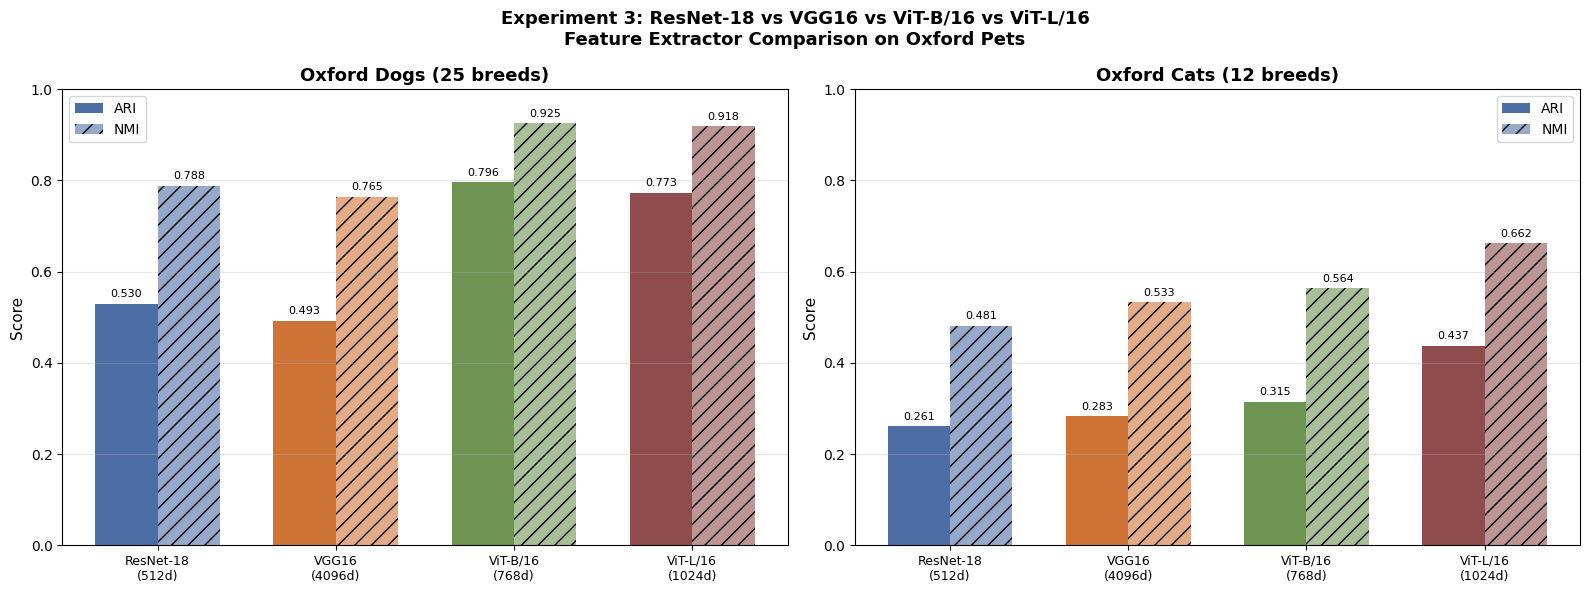

Saved: experiment3_architecture_vgg16.png


In [22]:
import matplotlib.pyplot as plt
import numpy as np

models_labels = ['ResNet-18\n(512d)', 'VGG16\n(4096d)', 'ViT-B/16\n(768d)', 'ViT-L/16\n(1024d)']
colors_model  = ['#2E5496', '#C55A11', '#538135', '#7B2C2C']

dog_ari = [0.5296, ox_dog_base['ari'], 0.7960, 0.7731]
dog_nmi = [0.7885, ox_dog_base['nmi'], 0.9254, 0.9181]
cat_ari = [0.2608, ox_cat_base['ari'], 0.3146, 0.4372]
cat_nmi = [0.4815, ox_cat_base['nmi'], 0.5637, 0.6618]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
width = 0.35

for ax, ari_vals, nmi_vals, title in [
    (axes[0], dog_ari, dog_nmi, 'Oxford Dogs (25 breeds)'),
    (axes[1], cat_ari, cat_nmi, 'Oxford Cats (12 breeds)'),
]:
    x     = np.arange(len(models_labels))
    bars1 = ax.bar(x - width/2, ari_vals, width, label='ARI',
                   color=colors_model, alpha=0.85)
    bars2 = ax.bar(x + width/2, nmi_vals, width, label='NMI',
                   color=colors_model, alpha=0.5, hatch='//')

    for bar in list(bars1) + list(bars2):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models_labels, fontsize=9)
    ax.set_ylim(0, 1.0)
    ax.set_ylabel('Score', fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle(
    'Experiment 3: ResNet-18 vs VGG16 vs ViT-B/16 vs ViT-L/16\n'
    'Feature Extractor Comparison on Oxford Pets',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(SAVE_DIR + 'experiment3_architecture_vgg16.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: experiment3_architecture_vgg16.png')

## Cell 19 — Final Master Comparison Table

Complete results across all experiments for the combined report.

In [23]:
print('='*85)
print('MASTER RESULTS — VGG16 Pipeline (All Experiments)')
print('='*85)

all_results = [
    # Experiment 1
    ('Exp 1', 'Imagewoof',   iw_base['name'],   iw_base['best_k'],   iw_base['ari'],   iw_base['nmi']),
    ('Exp 1', 'Imagewoof',   iw_black['name'],  iw_black['best_k'],  iw_black['ari'],  iw_black['nmi']),
    ('Exp 1', 'Imagewoof',   iw_white['name'],  iw_white['best_k'],  iw_white['ari'],  iw_white['nmi']),
    ('Exp 1', 'Oxford Dogs', ox_dog_base['name'],  ox_dog_base['best_k'],  ox_dog_base['ari'],  ox_dog_base['nmi']),
    ('Exp 1', 'Oxford Dogs', ox_dog_black['name'], ox_dog_black['best_k'], ox_dog_black['ari'], ox_dog_black['nmi']),
    ('Exp 1', 'Oxford Dogs', ox_dog_white['name'], ox_dog_white['best_k'], ox_dog_white['ari'], ox_dog_white['nmi']),
    ('Exp 1', 'Oxford Cats', ox_cat_base['name'],  ox_cat_base['best_k'],  ox_cat_base['ari'],  ox_cat_base['nmi']),
    ('Exp 1', 'Oxford Cats', ox_cat_black['name'], ox_cat_black['best_k'], ox_cat_black['ari'], ox_cat_black['nmi']),
    ('Exp 1', 'Oxford Cats', ox_cat_white['name'], ox_cat_white['best_k'], ox_cat_white['ari'], ox_cat_white['nmi']),
    # Experiment 2
    ('Exp 2', 'Oxford Dogs', 'Normal (1.0)',    lighting_results['normal']['dog']['best_k'],    lighting_results['normal']['dog']['ari'],    lighting_results['normal']['dog']['nmi']),
    ('Exp 2', 'Oxford Dogs', 'Dark (0.4)',      lighting_results['dark']['dog']['best_k'],      lighting_results['dark']['dog']['ari'],      lighting_results['dark']['dog']['nmi']),
    ('Exp 2', 'Oxford Dogs', 'Very Dark (0.2)', lighting_results['very_dark']['dog']['best_k'], lighting_results['very_dark']['dog']['ari'], lighting_results['very_dark']['dog']['nmi']),
    ('Exp 2', 'Oxford Cats', 'Normal (1.0)',    lighting_results['normal']['cat']['best_k'],    lighting_results['normal']['cat']['ari'],    lighting_results['normal']['cat']['nmi']),
    ('Exp 2', 'Oxford Cats', 'Dark (0.4)',      lighting_results['dark']['cat']['best_k'],      lighting_results['dark']['cat']['ari'],      lighting_results['dark']['cat']['nmi']),
    ('Exp 2', 'Oxford Cats', 'Very Dark (0.2)', lighting_results['very_dark']['cat']['best_k'], lighting_results['very_dark']['cat']['ari'], lighting_results['very_dark']['cat']['nmi']),
    # Experiment 3
    ('Exp 3', 'Oxford Dogs', 'VGG16 (4096d)',   ox_dog_base['best_k'], ox_dog_base['ari'], ox_dog_base['nmi']),
    ('Exp 3', 'Oxford Cats', 'VGG16 (4096d)',   ox_cat_base['best_k'], ox_cat_base['ari'], ox_cat_base['nmi']),
]

print(f'{"Exp":>5} {"Dataset":<15} {"Condition":<35} {"Best K":>6} {"ARI":>8} {"NMI":>8}')
print('-'*85)
for exp, dataset, condition, best_k, ari, nmi in all_results:
    print(f'{exp:>5} {dataset:<15} {condition:<35} {best_k:>6} {ari:>8.4f} {nmi:>8.4f}')
print('='*85)

master_df = pd.DataFrame([
    {'Experiment': exp, 'Dataset': dataset, 'Condition': condition,
     'Best K': best_k, 'ARI': round(ari, 4), 'NMI': round(nmi, 4)}
    for exp, dataset, condition, best_k, ari, nmi in all_results
])
master_df.to_csv(SAVE_DIR + 'master_results_vgg16.csv', index=False)
print('\nSaved: master_results_vgg16.csv')
print(f'All files saved to: {SAVE_DIR}')

MASTER RESULTS — VGG16 Pipeline (All Experiments)
  Exp Dataset         Condition                           Best K      ARI      NMI
-------------------------------------------------------------------------------------
Exp 1 Imagewoof       Imagewoof Baseline (VGG16)              12   0.5711   0.6797
Exp 1 Imagewoof       Imagewoof SAM Black bg (VGG16)           8   0.1707   0.3102
Exp 1 Imagewoof       Imagewoof SAM White bg (VGG16)           5   0.1316   0.2506
Exp 1 Oxford Dogs     Oxford Dogs Baseline VGG16              15   0.4927   0.7645
Exp 1 Oxford Dogs     Oxford Dogs Black bg VGG16              12   0.2058   0.5175
Exp 1 Oxford Dogs     Oxford Dogs White bg VGG16              20   0.3183   0.6075
Exp 1 Oxford Cats     Oxford Cats Baseline VGG16               5   0.2832   0.5327
Exp 1 Oxford Cats     Oxford Cats Black bg VGG16               5   0.1516   0.3252
Exp 1 Oxford Cats     Oxford Cats White bg VGG16               5   0.1938   0.4023
Exp 2 Oxford Dogs     Normal (1.0)